## Rotating Black Hole
In this excercise we have repeated measurments of mass and spin of several Kerr Black Holes.We assume that the mass measurements follow a normal distribution with mean $\mu = 1$ and width $\sigma = 0.02$,, while the spin values are drawn from a uniform distribution in the range $[0,1]$.

Our goal is to analyze how the irreducible mass evolves as the uncertainty on the mass measurments varies. In particula rwe analyze the distribution of the irreducible mass and compare it with the theoretical function $f(\chi)$ 
using the Kolmogorov Smirnov (KS) Test. This comparison is also extended to the distribution of the total mass for different values of $\sigma$ varies.
We define the irreducible mass and $f(\chi)$ as:
$$M_{\rm irr} =  M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}$$



$$f(\chi) = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}} = \frac{M_{\rm irr}}{M}$$

In [121]:
import numpy as np
from matplotlib import pyplot as plt
import random
import scipy
import astropy
from sklearn.neighbors import KernelDensity
from scipy.stats import norm
from tqdm.notebook import tqdm
from sklearn.model_selection import GridSearchCV

In [122]:
def f(chi):
    return np.sqrt((1+np.sqrt(1-chi**2))/2)
chi = np.random.uniform(0,1,10000)
M = norm(1, scale = 0.02).rvs(10000)


Text(0.5, 0, '$M_{\\odot}$')

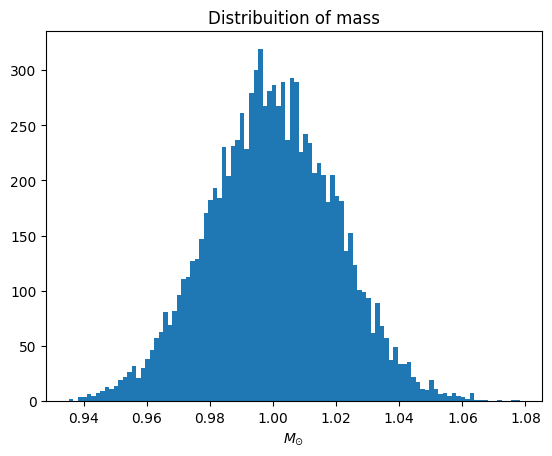

In [123]:
plt.hist(M, bins = 100)
plt.title("Distribuition of mass")
plt.xlabel(r"$M_{\odot}$")

Text(0.5, 0, '$M_{irr}$')

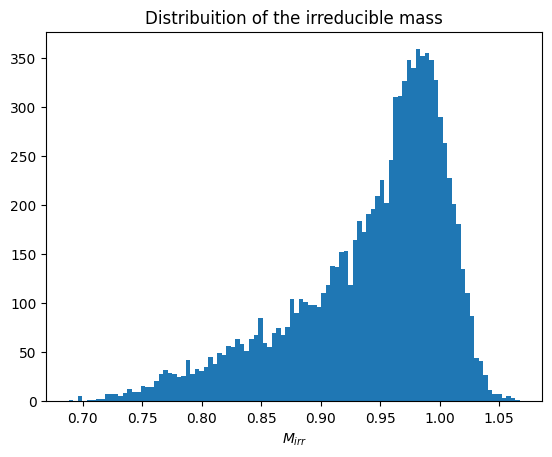

In [124]:
M_irr = M*f(chi)
plt.hist(M_irr, bins = 100)
plt.title("Distribuition of the irreducible mass")
plt.xlabel(r"$M_{irr}$")

Text(0.5, 0, '$M_{irr}$')

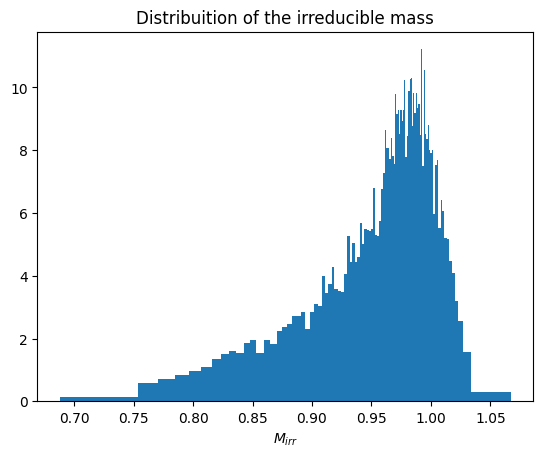

In [125]:
#setting an histogram of Mirr with each bin containing 100 points
bins100 = np.append(np.sort(M_irr)[::100], np.max(M_irr))
plt.hist(M_irr, bins = bins100, density = True)
plt.title("Distribuition of the irreducible mass")
plt.xlabel(r"$M_{irr}$")

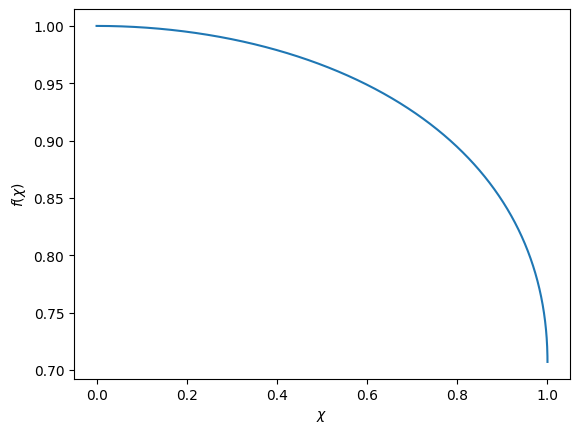

In [126]:
#f(chi) plot analitical form
chi_grid =np.linspace(0,1,len(chi))
plt.plot(chi_grid, f(chi_grid))
plt.xlabel(r"$\chi$")
plt.ylabel(r"$f(\chi)$")
plt.show()

Text(0.5, 0, '$f(\\chi)$')

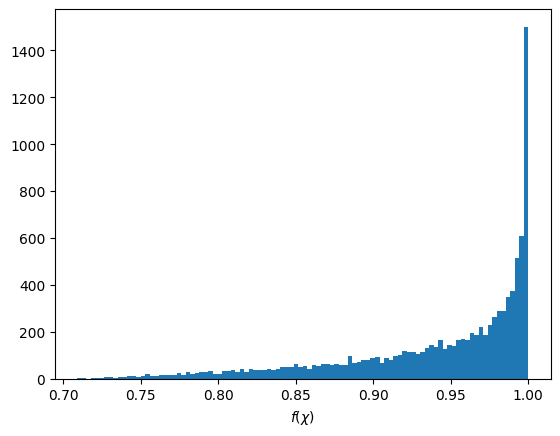

In [127]:
#f(chi) distribuition:
f_chi = f(chi)

plt.hist(f_chi, 100)
plt.xlabel(r"$f(\chi)$")


## $M_{irr}$ evolution as mass uncertainty varies

In [128]:
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Funzione f(chi)
def f(chi):
    return np.sqrt((1 + np.sqrt(1 - chi**2)) / 2)

n_samples = 100000
sigma_low = [0.001, 0.01]
sigma_high = [1, 10, 100]

# Chi in [0, 1]
chi = np.random.uniform(0, 1, n_samples)
f_chi = f(chi)

# Primo plot: sigma piccoli
plt.figure(figsize=(10, 5))
for s in sigma_low:
    M_var = norm(loc=1, scale=s).rvs(n_samples)
    M_irr_arr = f_chi * M_var
    bins100 = np.append(np.sort(M_irr_arr)[::100], np.max(M_irr_arr))
    plt.hist(M_irr_arr, bins=bins100, density=True, histtype='step', alpha=0.6, label=f'$\sigma$ = {s:.1e}')

# Overlay: f(chi)
bins_fchi = np.append(np.sort(f_chi)[::100], np.max(f_chi))
plt.hist(f_chi, bins=bins_fchi, density=True, histtype='stepfilled', alpha=0.5, label=r'$f(\chi)$')

# Overlay: M (sigma=1)
M_fixed = norm(loc=1, scale=1).rvs(n_samples)
bins_M = np.append(np.sort(M_fixed)[::100], np.max(M_fixed))
plt.hist(M_fixed, bins=bins_M, density=True, histtype='stepfilled', alpha=0.5, label=r'$M$, $\sigma = 1$')

plt.xlabel(r'$M_{\rm irr}$')
plt.ylabel('Probability Density')
plt.title(r'Distribution of $M_{\rm irr}$ for small $\sigma$')
plt.legend(prop={'size': 8})

plt.grid(True)
plt.tight_layout()
plt.show()

# Secondo plot: sigma grandi
plt.figure(figsize=(10, 5))
for s in sigma_high:
    M_var = norm(loc=1, scale=s).rvs(n_samples)
    M_irr_arr = f_chi * M_var
    bins100 = np.append(np.sort(M_irr_arr)[::100], np.max(M_irr_arr))
    plt.hist(M_irr_arr, bins=bins100, density=True, histtype='step', alpha=0.6, label=f'$\sigma$ = {s:.1e}')

# Overlay: f(chi)
plt.hist(f_chi, bins=bins_fchi, density=True, histtype='stepfilled', alpha=0.5, label=r'$f(\chi)$')

# Overlay: M (sigma=1)
plt.hist(M_fixed, bins=bins_M, density=True, histtype='stepfilled', alpha=0.5, label=r'$M$, $\sigma = 1$')

plt.xlabel(r'$M_{\rm irr}$')
plt.ylabel('Probability Density')
plt.title(r'Distribution of $M_{\rm irr}$ for large $\sigma$')
plt.legend(prop={'size': 8})

plt.grid(True)
plt.tight_layout()
plt.show()
"""

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
C:\Users\alexv\AppData\Local\Temp\ipykernel_19996\3353975791.py:24: SyntaxWarning: invalid escape sequence '\s'
  plt.hist(M_irr_arr, bins=bins100, density=True, histtype='step', alpha=0.6, label=f'$\sigma$ = {s:.1e}')


"\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom scipy.stats import norm\n\n# Funzione f(chi)\ndef f(chi):\n    return np.sqrt((1 + np.sqrt(1 - chi**2)) / 2)\n\nn_samples = 100000\nsigma_low = [0.001, 0.01]\nsigma_high = [1, 10, 100]\n\n# Chi in [0, 1]\nchi = np.random.uniform(0, 1, n_samples)\nf_chi = f(chi)\n\n# Primo plot: sigma piccoli\nplt.figure(figsize=(10, 5))\nfor s in sigma_low:\n    M_var = norm(loc=1, scale=s).rvs(n_samples)\n    M_irr_arr = f_chi * M_var\n    bins100 = np.append(np.sort(M_irr_arr)[::100], np.max(M_irr_arr))\n    plt.hist(M_irr_arr, bins=bins100, density=True, histtype='step', alpha=0.6, label=f'$\\sigma$ = {s:.1e}')\n\n# Overlay: f(chi)\nbins_fchi = np.append(np.sort(f_chi)[::100], np.max(f_chi))\nplt.hist(f_chi, bins=bins_fchi, density=True, histtype='stepfilled', alpha=0.5, label=r'$f(\\chi)$')\n\n# Overlay: M (sigma=1)\nM_fixed = norm(loc=1, scale=1).rvs(n_samples)\nbins_M = np.append(np.sort(M_fixed)[::100], np.max(M_fixed))\nplt.hist(M_fix

## KS Test with varying uncertainty

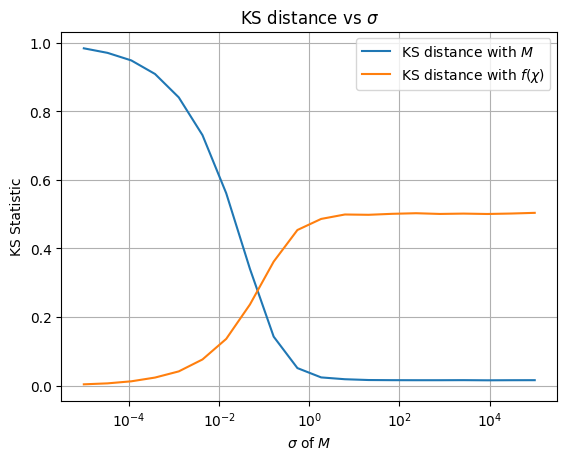

In [129]:
sigma = np.logspace(-5,5,20)
dist_f = []
dist_m = []
N = 10**5
chi = np.random.uniform(0, 1, N)
f_chi = f(chi)

for s in sigma:
    M_var = np.random.normal(1, scale = s, size =  N)
    M_irr_arr = f_chi*M_var
    ks_m = scipy.stats.ks_2samp(M_var, M_irr_arr) #computing the maximum distance between the two cdf
    ks_f = scipy.stats.ks_2samp(f_chi, M_irr_arr)

    dist_m.append(ks_m)
    dist_f.append(ks_f)

ks_stat_M = [r.statistic for r in dist_m]
ks_stat_f = [r.statistic for r in dist_f]

plt.plot(sigma, ks_stat_M, label=r'KS distance with $M$')
plt.plot(sigma, ks_stat_f, label=r'KS distance with $f(\chi)$')
plt.semilogx()
plt.xlabel(r'$\sigma$ of $M$')
plt.ylabel('KS Statistic')
plt.legend()
plt.grid(True)
plt.title(r'KS distance vs $\sigma$')
plt.show()

- For large $\sigma$, $M_{irr}$ follow the distribuition of M (i.e the distance between the cdfs of the two distribuition goes to zero)
- For small $\sigma$, $M_{irr}$ follow the distribuition of $f(\chi)$

## KDE 
To visualize the distribution of our data, we can use Kernel Density Estimation (KDE). This technique assigns a smooth kernel (typically a Gaussian) to each data point, with a specified bandwidth. The overall probability density function is then obtained by summing all these kernels across the domain.

In [160]:
def kde_sklearn(data, bandwidth , kernel):
    xgrid = np.linspace(data.min(),data.max(),len(data)) 
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)

    return np.exp(log_pdf), xgrid

In [161]:
N = 10000
M = norm(1, scale = 0.02).rvs(N)

(10000,)
0.001


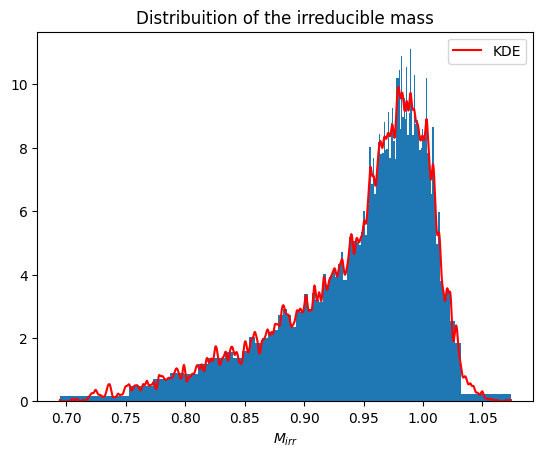

In [162]:
#K-Fold cross validation to find the optimal bandwidth
bwrange = np.linspace(0.001,1.0, 10)
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= 5) # Try each bandwidth with 5-folds
chi = np.random.uniform(0,1,10000)
f_chi = f(chi)
M_irr = M*f(chi)
M_irr_cv = M_irr[:, np.newaxis]
print(M_irr.shape)
grid.fit(M_irr_cv) 
h_opt = grid.best_params_['bandwidth']
print(h_opt)

pdf, xgrid = kde_sklearn(M_irr, h_opt, kernel = 'gaussian')
# KDE Plot
plt.plot(xgrid,pdf, c='red', label = 'KDE')

#comparing with histogram
bins100 = np.append(np.sort(M_irr)[::100], np.max(M_irr))
plt.hist(M_irr, bins = bins100, density = True)
plt.title("Distribuition of the irreducible mass")
plt.xlabel(r"$M_{irr}$")
plt.legend()
plt.show()

The pdf of $M_{irr}$ and $f(\chi)$ have the following mathematical form:
\begin{equation}
\pi(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}}\,.
\end{equation}

\begin{equation}
p(M_{\rm irr})  = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}}  \,\, {\rm d}f\,. \label{pmirr}
\end{equation}

In [163]:
def pi(f_chi):
    num = 2*(2*(f_chi**2)-1)
    den = np.sqrt(1-(f_chi)**2)
    return num/den
scale = 0.02
def integrand(f,x):
    return ((2/np.pi)**0.5 / scale ) * np.exp(-(x/f -1)**2 /(2*scale**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f
f_dom = np.linspace(1/2**0.5,1,len(xgrid)) #domain of f(chi)
Mirr_teo = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(xgrid)]

  0%|          | 0/10000 [00:00<?, ?it/s]

Let's compare the theoretical form of the two pdf with the KDE


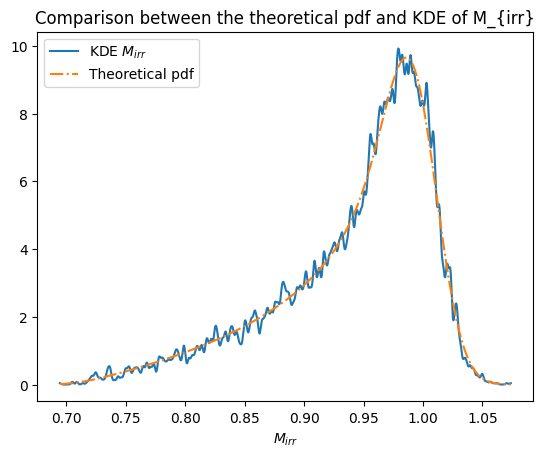

In [164]:
plt.plot(xgrid, pdf, label = r'KDE $M_{irr}$')
plt.plot(xgrid, Mirr_teo, label = 'Theoretical pdf', linestyle = '-.')
plt.xlabel(r'$M_{irr}$')
plt.title(r"Comparison between the theoretical pdf and KDE of M_{irr}")
plt.legend()
plt.show()

In [165]:
bwrange = np.linspace(0.001,1.0, 10)
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= 5) # Try each bandwidth with 5-folds



f_chi_cv = f_chi[:, np.newaxis]
grid.fit(f_chi_cv) 
h_opt = grid.best_params_['bandwidth']
print(h_opt)


0.001


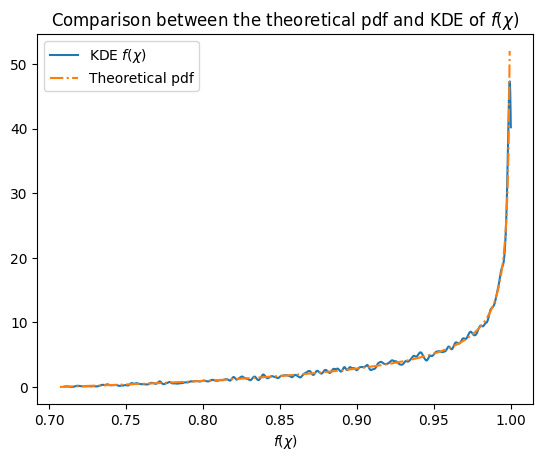

In [166]:
pi_f, xgrid_f = kde_sklearn(f_chi, h_opt, kernel = 'gaussian')
plt.plot(xgrid_f, pi_f, label = r'KDE $f(\chi)$')
f_grid = np.linspace(1/2**0.5,1,400)[:-1]
plt.plot(f_grid, pi(f_grid), label = 'Theoretical pdf', linestyle = '-.')
plt.xlabel(r'$f(\chi)$')
plt.title(r"Comparison between the theoretical pdf and KDE of $f(\chi)$")
plt.legend()
plt.show()

From the previous plots we can say that the KDE of the distribuitions are in line with the theoretical models 